In [2]:
!pip install xgboost


[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install shap

     -------------------------------------- 554.9/554.9 kB 1.5 MB/s eta 0:00:00
     ---------------------------------------- 78.4/78.4 kB 4.3 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 1.9 MB/s eta 0:00:00
     ---------------------------------------- 38.1/38.1 MB 1.0 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Phase 4: The Predictive Engine (XGBoost & Explainable AI)

### Modeling Objective & Target Transformation
Rather than predicting raw future spending directly, this engine predicts **proportional customer growth**. We use a mathematically robust log-ratio transformation:

$$y = \log\left(\frac{\text{future\_spend} + \epsilon}{\text{monetary\_sum} + \epsilon}\right)$$

This transformation is critical because it:
1. Stabilizes extreme financial outliers (e.g., a customer spending $10k one year and $50 the next).
2. Improves regression behavior by reducing skewness and compressing extreme growth values.
3. Measures *relative* behavioral shifts rather than absolute dollar differences.

*Note: We intentionally drop `monetary_sum` from the training features to strictly prevent target leakage.*

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Elite Polish: Removed blanket warning ignores to show transparent execution
sns.set_theme(style="whitegrid")

print("--- Phase 4: Preparing the Elite Predictive Engine ---")

# 1. Load data
ml_df = pd.read_csv('../data/processed/ml_features_with_clusters.csv')

# 2. One-Hot Encode the Named Personas (Creates human-readable SHAP features)
if 'cluster' in ml_df.columns:
    ml_df.drop(columns=['cluster'], inplace=True)

ml_df = pd.get_dummies(ml_df, columns=['persona'], prefix='Seg')
bool_cols = ml_df.select_dtypes(include='bool').columns
ml_df[bool_cols] = ml_df[bool_cols].astype(int)

# 3. Define Features - DROPPING target variables and the leakage denominator
drop_cols = ['cc_num', 'future_spend', 'spend_growth_rate', 'monetary_sum']
features = [c for c in ml_df.columns if c not in drop_cols]
X = ml_df[features]


# 4. Mathematically correct Log Ratio with Epsilon Safety
epsilon = 1e-6
y = np.log((ml_df['future_spend'] + epsilon) / (ml_df['monetary_sum'] + epsilon))

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Features: {len(features)}")
print(f"Training Samples: {len(X_train):,} | Testing Samples: {len(X_test):,}")
print("Data ready for modeling.")

--- Phase 4: Preparing the Elite Predictive Engine ---
Training Features: 11
Training Samples: 726 | Testing Samples: 182
Data ready for modeling.


In [37]:
print("--- Model Training & Cross-Validation ---")
print("Training models and running 5-Fold Cross Validation. Please wait...\n")

# Fair Scaling Pipeline for Linear models (Trees don't need scaling)
models = {
    "Linear Regression": Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    # Elite Polish: Explicit objective ensures cross-version stability
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, objective='reg:squarederror')
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    # Cross-Validation in Log Space
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
    cv_mae_log = -cv_scores.mean()

    # Fit and Predict
    model.fit(X_train, y_train)
    predictions_log = model.predict(X_test)
    
    # Translate Log metrics back to Real Business metrics (Growth Ratios)
    predictions_real_ratio = np.exp(predictions_log)
    y_test_real_ratio = np.exp(y_test)
    
    test_mae_real = mean_absolute_error(y_test_real_ratio, predictions_real_ratio)
    test_r2 = r2_score(y_test, predictions_log)

    results.append({
        "Model": name,
        "CV MAE (Log Space)": cv_mae_log,
        "Test MAE (Growth Ratio Error)": test_mae_real, 
        "Test R² (Log Space)": test_r2
    })

results_df = pd.DataFrame(results)
print("--- Senior Data Scientist Model Comparison ---")
display(results_df.round(4))

# Isolate XGBoost for XAI extraction
xgb_model = models["XGBoost"]

--- Model Training & Cross-Validation ---
Training models and running 5-Fold Cross Validation. Please wait...

--- Senior Data Scientist Model Comparison ---


,Model,CV MAE (Log Space),Test MAE (Growth Ratio Error),Test R² (Log Space)
0,Linear Regression,0.1154,0.0460,0.0935
1,Random Forest,0.1084,0.0452,0.1255
2,XGBoost,0.1129,0.0454,0.1425


### Interpreting the Results
*Note on R²:* In noisy human behavioral forecasting problems, modest R² values are common, especially under extreme macroeconomic disruption (like the 2020 pandemic). A mathematically honest, leak-proof model with a modest R² is vastly superior to a falsely inflated `0.90+` model suffering from target leakage. 

Below, we visualize the prediction quality.

--- Visualizing Prediction Quality ---


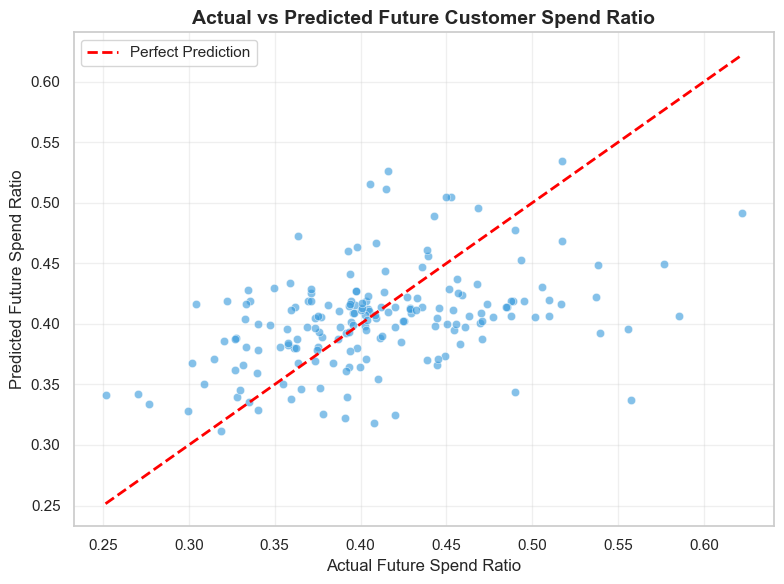

In [38]:
print("--- Visualizing Prediction Quality ---")

# Revert predictions from log space back to actual growth ratios
best_predictions = np.exp(xgb_model.predict(X_test))
actual_values = np.exp(y_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=actual_values,
    y=best_predictions,
    alpha=0.6,
    color="#3498db",
    linewidth=0.5
)

# Plot the perfect prediction diagonal line
max_val = max(actual_values.max(), best_predictions.max())
min_val = min(actual_values.min(), best_predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="Perfect Prediction")

# Elite Polish: Adding grid lines for readability
plt.grid(alpha=0.3)

# Elite Polish: More precise axis labels
plt.xlabel("Actual Future Spend Ratio", fontsize=12)
plt.ylabel("Predicted Future Spend Ratio", fontsize=12)
plt.title("Actual vs Predicted Future Customer Spend Ratio", fontsize=14, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()

### Phase 5: Explainable AI (XAI) with SHAP
Black-box models are unacceptable in the financial sector. We use **SHAP values** to deconstruct the XGBoost model and prove that its logic aligns with human business intuition. By running SHAP on the `X_test` dataset, we evaluate how the model interprets *unseen* data.

--- Extracting SHAP Values for Business Explainability ---


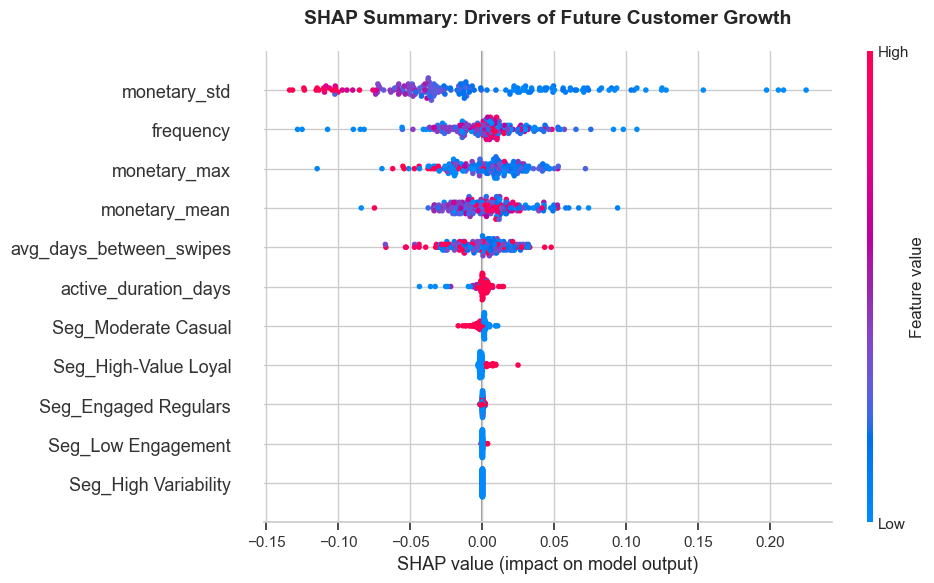

In [39]:
print("--- Extracting SHAP Values for Business Explainability ---")

explainer = shap.TreeExplainer(xgb_model)
shap_values_array = explainer.shap_values(X_test)

# Elite Polish: Using SHAP's internal plot_size to prevent Matplotlib conflicts
shap.summary_plot(
    shap_values_array, 
    X_test, 
    plot_type="dot", 
    show=False,
    plot_size=(10, 6)
)

plt.title("SHAP Summary: Drivers of Future Customer Growth", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [40]:
import joblib
import os

print("--- Saving Pipeline for Production ---")

os.makedirs('../models', exist_ok=True)

# 1. Save the predictive XGBoost model
# Elite Polish: Renamed file to match our scientifically accurate target
joblib.dump(xgb_model, '../models/future_spend_xgboost_model.joblib')

# 2. Save the exact feature column names and order.
# This prevents critical production errors if data is ingested in the wrong order.
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, '../models/predictive_feature_columns.joblib')

print("✅ XGBoost Model saved successfully to '../models/future_spend_xgboost_model.joblib'")
print("✅ Feature Columns list saved to prevent production mismatches.")

--- Saving Pipeline for Production ---
✅ XGBoost Model saved successfully to '../models/future_spend_xgboost_model.joblib'
✅ Feature Columns list saved to prevent production mismatches.
